# TARDIS — Analytics des retards ferroviaires (EDA & cleaning)

## Fil conducteur

1. **Problème** — Jeu tabulaire OD × mois pour analyser punctuality, retards, annulations.
2. **Qualité** — Formats mixtes, NA, labels bruités, doublons, colonnes commentaires (hors scope NLP).
3. **Cleaning** — Preuve visuelle (avant/après), puis normalisation stations / `Service`, types, doublons.
4. **Features** — Calendrier, `route`, ratios métier (`cancel_rate`, `severe_delay_rate`, …).
5. **EDA** — Distributions, corrélations, série temporelle, gares / routes.
6. **Livrable** — `cleaned_dataset.csv`.

## 1. Imports & configuration

In [24]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")

FIG = {"sm": (10, 5), "md": (10, 6), "lg": (12, 5), "xl": (14, 7), "sq": (8, 6), "heat": (14, 10)}
PAL = {"delay": "#4a90a4", "route": "crest", "box": "pastel"}
PAL_CANCEL_BAR = "rocket"
CMAP = {"missing": "YlOrRd", "corr": "coolwarm"}

sns.set_theme(style="whitegrid")
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.titlesize"] = 14

## 2. Chargement

### 2.0 Lecture CSV + `strip` des noms de colonnes

Juste après ces deux lignes, on crée **`raw_df = df.copy()`** : c’est la **référence « avant nettoyage »** (plus tard le notebook modifie **`df`** seulement ; **`raw_df`** ne doit pas être réécrit).

In [25]:
CSV_PATH = "dataset.csv"

df = pd.read_csv(CSV_PATH, sep=";", na_values=["N/A", "", " "], engine="python")
df.columns = df.columns.str.strip()

# Snapshot avant tout nettoyage : obligatoire pour les sections 6 et 7 (avant / après)
raw_df = df.copy()

print("Shape df (après strip colonnes) :", df.shape)
print("Exemple de colonnes :", list(df.columns[:6]), "...")
print("raw_df cree : copie independante de df ?", raw_df is not df)

Shape df (après strip colonnes) : (10840, 26)
Exemple de colonnes : ['Date', 'Service', 'Departure station', 'Arrival station', 'Average journey time', 'Number of scheduled trains'] ...
raw_df cree : copie independante de df ? True


### 2.1 La variable `raw_df` (preuve dans les sorties)

La cellule suivante affiche explicitement **`raw_df`** (aperçu). Si tu ne vois pas **`raw_df`** dans ton IDE, recharge le fichier depuis le disque (**Revert File**) : tu regardes peut‑être une ancienne version du notebook.

In [26]:
# Reference avant nettoyage — meme contenu que df a ce stade, objet pandas distinct
assert raw_df is not df
print("raw_df.shape :", raw_df.shape)
print("Colonnes (extrait) :", list(raw_df.columns[:8]))
display(raw_df.head(3))

raw_df.shape : (10840, 26)
Colonnes (extrait) : ['Date', 'Service', 'Departure station', 'Arrival station', 'Average journey time', 'Number of scheduled trains', 'Number of cancelled trains', 'Cancellation comments']


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Departure delay comments,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Arrival delay comments,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,NaN,5,NaN,289,11.25,3.693,NaN,147,28.44,6.511,NaN,110,346.5,44,8,36.13,31.09,10.92,15.97,5.042,75.92
1,2018-01,National,LA ROCHELLE VILLE,PARIS MONTPARNASSE,165,222,NaN,NaN,8,2.875,0.0958,NaN,34,21.52,5.696,NaN,22,5.696,5,NaN,15.38,30.77,38.46,11.54,3.846,0
2,2018-01,National,PARIS MONTPARNASSE,QUIMPER,220,248,1,NaN,37,9.501,NaN,NaN,NaN,55.69,7.579,"Ce mois-ci, l'OD a été touchée par les inciden...",26,7.548,17,7,26.92,38.46,NaN,19.23,0,0


## 3. Inspection initiale

In [27]:
display(df.head())

print("\n--- info() ---")
df.info()

print("\n--- describe() — numériques ---")
display(df.describe())

print("\n--- describe(include=['object']) ---")
display(df.describe(include=["object"]))

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Departure delay comments,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Arrival delay comments,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,NaN,5,NaN,289,11.25,3.693,NaN,147,28.44,6.511,NaN,110,346.5,44,8,36.13,31.09,10.92,15.97,5.042,75.92
1,2018-01,National,LA ROCHELLE VILLE,PARIS MONTPARNASSE,165,222,NaN,NaN,8,2.875,0.0958,NaN,34,21.52,5.696,NaN,22,5.696,5,NaN,15.38,30.77,38.46,11.54,3.846,0
2,2018-01,National,PARIS MONTPARNASSE,QUIMPER,220,248,1,NaN,37,9.501,NaN,NaN,NaN,55.69,7.579,"Ce mois-ci, l'OD a été touchée par les inciden...",26,7.548,17,7,26.92,38.46,NaN,19.23,0,0
3,2018j01,National,PARIS MONTPARNASSE,ST MALO,156,102,0,NaN,12,19.91,1.967,NaN,13,48.62,6.791,"Ce mois-ci, l'OD a été touchée par les inciden...",8,6.725,6,4,23.08,218.7,7.692,15.38,7.692,NaN
4,2018-01,National,PARIS MONTPARNASSE,ST PIERRE DES CORPS,61,391,2,NaN,61,NaN,0.8869,NaN,71,12.41,3.346,NaN,17,3.346,6,0,21.21,42.42,9.091,21.21,6.061,0



--- info() ---
<class 'pandas.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 26 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   Date                                                                           10299 non-null  str    
 1   Service                                                                        10288 non-null  str    
 2   Departure station                                                              10298 non-null  str    
 3   Arrival station                                                                10293 non-null  str    
 4   Average journey time                                                           10010 non-null  float64
 5   Number of scheduled trains                                                     10018 non-null  float64
 6   Number of cancell

,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Departure delay comments,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
count,1.001e+04,1.002e+04,1.001e+04,0,1.001e+04,1.003e+04,1.002e+04,0,1.002e+04,1.002e+04,1.002e+04,1.001e+04,1.002e+04,1.001e+04,1e+04,1.002e+04,1.001e+04,1.002e+04,1.002e+04,1.002e+04,1.002e+04
mean,250.6,394.5,13.97,NaN,127.9,17.38,4.492,NaN,53.88,50.58,8.56,38.3,51.36,18.35,6.784,32.12,32.26,29.22,27.82,10.56,11.18
std,351.7,567.8,29.96,NaN,195.7,26.39,7.891,NaN,79.53,70.49,13.99,56.51,72.72,27.58,10.63,46.59,46.5,42.23,40.16,16.43,17.94
min,0,0,0,NaN,0,0,-229.3,NaN,0,-30.51,-472.6,0,-4,0,0,0,0,0,0,0,0
25%,104,153,0,NaN,23,6.012,1.226,NaN,15,25.67,3.365,11,26.9,5,1,11.11,12.5,10.26,10.34,0,0
50%,168,236,2,NaN,58,10.29,2.422,NaN,30,33.63,5.403,22,37.25,10,3,20,21.05,19.05,18.18,6,5.357
75%,230,402,10,NaN,145,16.45,4.337,NaN,56,43.72,8.447,39,47.85,19,7,33.33,32,30,28.12,12,12.77
max,1703,2681,297,NaN,872.3,270.4,84.52,NaN,376,345.3,92,312,346.5,202,71,218.9,218.7,198.8,190.4,100,100



--- describe(include=['object']) ---


C:\Users\mathi\AppData\Local\Temp\ipykernel_18888\1399507771.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object"]))


,Date,Service,Departure station,Arrival station,Arrival delay comments
count,10299,10288,10298,10293,686
unique,370,238,346,343,311
top,2018-08,National,PARIS LYON,PARIS LYON,"Ce mois-ci, l'OD a été touchée par les inciden..."
freq,135,8781,2038,2032,32


### Observations — inspection initiale

**Shape :** 10 840 lignes × 26 colonnes. Granularité : une ligne = une paire OD (origine-destination) × un mois.

**Problèmes de types détectés :**
- `Date` → `str` alors que ça devrait être `datetime`. À convertir en `%Y-%m`.
- `Service`, `Departure station`, `Arrival station` → `str` OK pour l'instant, mais à encoder pour le modèle.
- `Cancellation comments` et `Departure delay comments` → parsées en `float64` (pandas a tout avalé comme NaN). Pas un vrai type numérique : ce sont des colonnes texte vides.

**Valeurs aberrantes dans `describe()` :**
- `Average delay of all trains at departure` → min à **-229 min**. Un retard négatif n'existe pas. À investiguer.
- `Average delay of all trains at arrival` → min à **-472 min**. Même problème, encore plus extrême.
- `Average journey time` → min à **0 min**. Un trajet de 0 minute est incohérent.
- `Number of scheduled trains` → max à **2681**, mais min à **0**. Des lignes avec 0 trains programmés ?

**Variable cible (target) :** `Average delay of all trains at arrival` — c'est le retard moyen à l'arrivée en minutes. C'est ce que le modèle devra prédire.

## 4. Valeurs manquantes (audit)

,missing_count,missing_pct
Cancellation comments,10840,100
Departure delay comments,10840,100
Arrival delay comments,10154,93.67
Number of trains delayed > 60min,836,7.71
Pct delay due to infrastructure,831,7.67
Average journey time,830,7.66
Number of cancelled trains,828,7.64
Number of trains delayed > 15min,828,7.64
Number of trains delayed > 30min,828,7.64
Number of trains delayed at departure,826,7.62


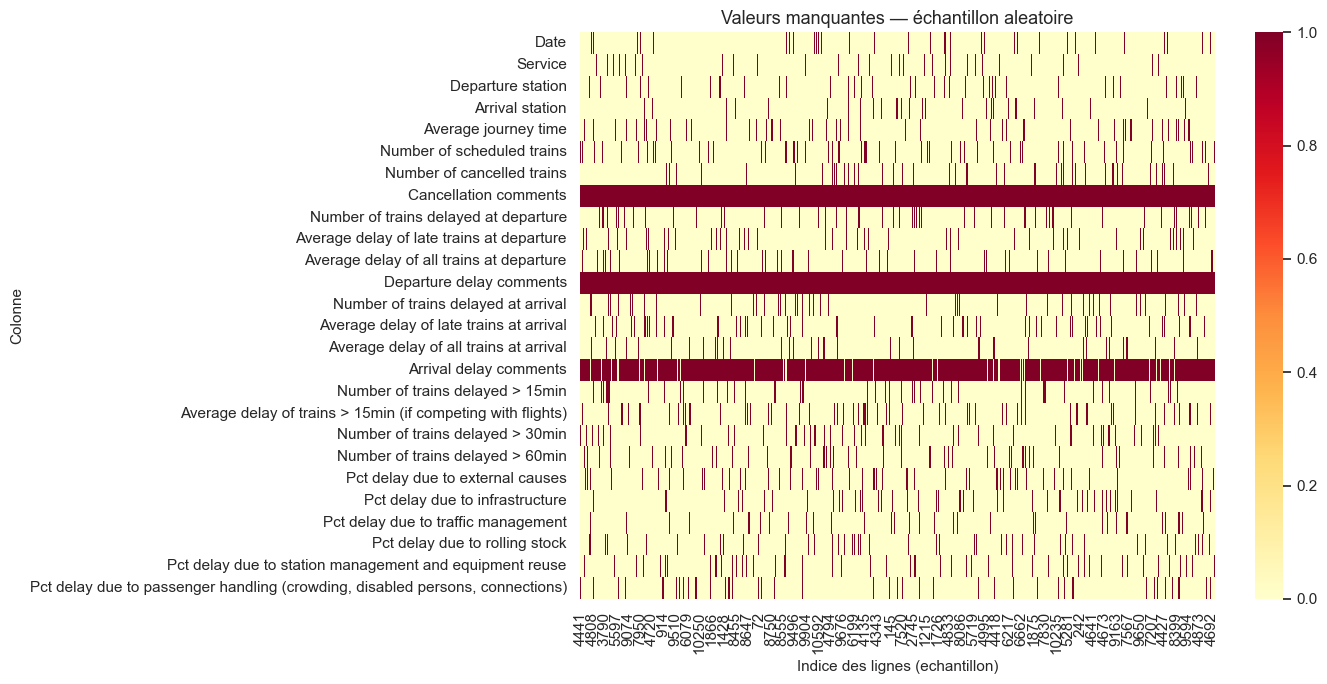

Taux global de cellules manquantes dans l'echantillon : 17.62 % (sur 20,800 cellules).


In [28]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct}).sort_values(
    "missing_pct", ascending=False
)
display(missing_df)

sample_size = min(800, len(df))
rng = np.random.default_rng(42)
sample_idx = rng.choice(df.index, size=sample_size, replace=False)
missing_sample = df.loc[sample_idx].isna()

fig, ax = plt.subplots(figsize=FIG["xl"])
sns.heatmap(missing_sample.T, cbar=True, yticklabels=True, cmap=CMAP["missing"], ax=ax)
ax.set_title("Valeurs manquantes — échantillon aleatoire", fontsize=13)
ax.set_xlabel("Indice des lignes (echantillon)")
ax.set_ylabel("Colonne")
plt.tight_layout()
plt.show()

tot_cells = missing_sample.shape[0] * missing_sample.shape[1]
share_miss = missing_sample.to_numpy().mean() * 100
print(f"Taux global de cellules manquantes dans l'echantillon : {share_miss:.2f} % (sur {tot_cells:,} cellules).")

### Problèmes dataset — valeurs manquantes

**Critique (impact direct sur le modèle) :**
- `Date`, `Departure station`, `Arrival station`, `Service` → **~5 % de NA**. Ce sont des features clés. Ces lignes sont probablement à supprimer ou investiguer — on ne peut pas imputer une gare ou une date.
- Toutes les colonnes numériques métier → **~7.6 % de NA en bloc**. C'est le même batch de lignes : très probablement des entrées vides dans le CSV source. Décision probable : suppression des lignes concernées.

**Secondaire (pas de valeur pour le modèle) :**
- `Cancellation comments`, `Departure delay comments` → **100 % vides**. Suppression directe, sans hésitation.
- `Arrival delay comments` → **93.7 % vide**. Même décision : suppression. On ne fait pas de NLP ici.

**Conclusion provisoire :** les NA semblent systémiques (même taux, même lignes) — pas aléatoires. La stratégie de nettoyage sera donc majoritairement par suppression de lignes, pas par imputation.

## 5. Doublons (avant nettoyage métier)

In [29]:
n_dup = df.duplicated().sum()
pct_dup = 100 * n_dup / len(df)
print(f"Lignes dupliquees : {n_dup} ({pct_dup:.3f} % du fichier brut).")

Lignes dupliquees : 178 (1.642 % du fichier brut).


### Problèmes dataset — doublons

**178 doublons** détectés sur 10 840 lignes (~1.6 %).

C'est marginal en volume, mais problématique pour le modèle : une même paire OD × mois apparaissant deux fois avec les mêmes valeurs fausserait les métriques et introduirait du data leakage si ces lignes se retrouvent à cheval sur le train set et le test set.

Origine probable : exports multiples du même fichier source, ou agrégations redondantes côté SNCF.

Décision : `drop_duplicates(keep='first')` — déjà prévu en section 7.

## 6. Preuve visuelle du nettoyage (état brut)

Avant d’appliquer les transformations définitives, on documente :

1. **Commentaires** — échantillon du bruit textuel (colonnes supprimées ensuite).
2. **Dates invalides** — pas seulement le décompte : exemples de chaînes qui ne parsèment pas en `%Y-%m`.
3. **Colonnes `object` à forte teneur numérique** — quelles colonnes sont encore typées object alors qu’elles devraient être numériques ; **valeurs problématiques** (`"-"`, `unknown`, séparateur décimal `,`, etc.).
4. **`Service`** — cardinalité brute et extrait des modalités les plus fréquentes.
5. **Stations** — cardinalité départ / arrivée avant normalisation texte.

*(Les métriques « après » viennent après la section nettoyage.)*

### 6.1 Commentaires : bruit réel avant suppression

In [30]:
COMMENT_PREVIEW = [
    "Cancellation comments",
    "Departure delay comments",
    "Arrival delay comments",
]
for col in COMMENT_PREVIEW:
    if col not in raw_df.columns:
        continue
    s = raw_df[col].dropna()
    if len(s) == 0:
        print(f"{col}: (vide)")
        continue
    print(f"\n--- Echantillon aleatoire : {col} ---")
    display(s.sample(min(5, len(s)), random_state=42))

Cancellation comments: (vide)
Departure delay comments: (vide)

--- Echantillon aleatoire : Arrival delay comments ---


942     Ce mois-ci, l'OD a été touchée par les inciden...
2412    Le 02 Juillet  ce sont  les conséquences des i...
878     •panne du 5180, problème de disjonction, à Aix...
1102    Accident de personne à chevry, restitution tar...
1006    •problème de traction du 9582 vers Aix-en-Prov...
Name: Arrival delay comments, dtype: str

### 6.2 Dates : valeurs invalides (pas seulement le total)

In [31]:
if "Date" in raw_df.columns:
    parsed = pd.to_datetime(raw_df["Date"], format="%Y-%m", errors="coerce")
    invalid_mask = parsed.isna() & raw_df["Date"].notna()
    n_invalid = int(invalid_mask.sum())
    print(f"Lignes avec Date non parsable (non NA brute mais NaT apres coerce) : {n_invalid}")
    if n_invalid > 0:
        bad = raw_df.loc[invalid_mask, "Date"]
        print("Exemples de valeurs brutes problematiques (uniques, max 15) :")
        print(bad.astype(str).unique()[:15])
        print("\nApercu des premieres lignes concernees :")
        display(raw_df.loc[invalid_mask].head(10))
else:
    print("Colonne Date absente.")

Lignes avec Date non parsable (non NA brute mais NaT apres coerce) : 278
Exemples de valeurs brutes problematiques (uniques, max 15) :
<ArrowStringArray>
['2018j01', '2018-r1', '2018P01', '2018-u1', 'x018-01', '201s-02', 'G018-02', '201n-02', '20U8-02', '2018v03',
 'k018-03', '2018g03', '2018-53', '2018-0h', '2018-L4']
Length: 15, dtype: str

Apercu des premieres lignes concernees :


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Departure delay comments,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Arrival delay comments,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
3,2018j01,National,PARIS MONTPARNASSE,ST MALO,156,102,0,NaN,12,19.91,1.967,NaN,13,48.62,6.791,"Ce mois-ci, l'OD a été touchée par les inciden...",8,6.725,6,4,23.08,218.7,7.692,15.38,7.692,NaN
63,2018-r1,National,METZ,PARIS EST,85,307,1,NaN,NaN,8.047,NaN,NaN,64,14.52,3.32,NaN,17,3.32,8,0,18.92,8.108,37.84,29.73,2.703,2.703
90,2018P01,National,VANNES,PARIS MONTPARNASSE,156,278,1,NaN,168,5.12,3.131,NaN,37,30.07,6.264,NaN,25,6.241,11,NaN,24.14,44.83,20.69,3.448,3.448,3.448
94,2018-u1,National,AVIGNON TGV,PARIS LYON,159,538,0,NaN,109,11.69,2.113,NaN,88,31.97,5.798,NaN,62,5.798,35,12,36.47,24.71,16.47,18.82,0,3.529
117,x018-01,National,LE CREUSOT MONTCEAU MONTCHANIN,PARIS LYON,81,224,1,NaN,127,9.93,5.653,NaN,45,21.4,3.625,NaN,260.4,3.625,9,2,26.19,16.67,30.95,16.67,9.524,0
189,201s-02,National,PARIS EST,NANCY,94,268,4,NaN,70,13.82,3.643,NaN,38,25.52,6.343,NaN,44,6.343,124.7,4,61.29,0,9.677,25.81,3.226,0
212,G018-02,National,PARIS MONTPARNASSE,BORDEAUX ST JEAN,144,698,46,NaN,189,15.51,4.281,NaN,157,41.85,10.11,"Ce mois-ci, l'OD a été touchée par les inciden...",123,10.11,72,27,49.66,15.65,14.29,17.69,2.721,0
221,201n-02,National,PARIS NORD,DUNKERQUE,120,256,13,NaN,81,14.64,4.864,NaN,48,38.5,8.206,NaN,39,8.206,25,NaN,50,14.58,6.25,27.08,2.083,NaN
241,20U8-02,NaN,POITIERS,PARIS MONTPARNASSE,94,456,38,NaN,207,9.446,4.679,NaN,365.3,32.8,13.03,"Ce mois-ci, l'OD a été touchée par les inciden...",93,13.03,46,22,49.49,15.15,14.14,13.13,6.061,2.02
294,2018v03,National,PARIS MONTPARNASSE,QUIMPER,NaN,NaN,5,NaN,NaN,11.24,1.322,NaN,19,57.37,5.469,"Ce mois-ci, l'OD a été touchée par les inciden...",19,5.469,14,NaN,22.22,27.78,16.67,33.33,72.04,0


### 6.3 Colonnes `object` → numériques : diagnostic et valeurs problématiques

In [32]:
object_cols = list(raw_df.select_dtypes(include=["object"]).columns)
numeric_like = []
for col in object_cols:
    conv = pd.to_numeric(raw_df[col], errors="coerce")
    nn = raw_df[col].notna().sum()
    if nn == 0:
        continue
    ok = conv.notna().sum()
    if ok / nn >= 0.5:
        numeric_like.append(col)

print("Colonnes encore 'object' mais majoritairement convertibles en numerique :")
print(numeric_like if numeric_like else "(aucune detectee avec seuil 50 %)")

for col in numeric_like:
    problematic = raw_df.loc[
        pd.to_numeric(raw_df[col], errors="coerce").isna() & raw_df[col].notna(), col
    ]
    if len(problematic) > 0:
        print(f"\nValeurs problematiques dans `{col}` (echantillon unique, max 10) :")
        print(problematic.astype(str).unique()[:10])

Colonnes encore 'object' mais majoritairement convertibles en numerique :
(aucune detectee avec seuil 50 %)


C:\Users\mathi\AppData\Local\Temp\ipykernel_18888\1969350372.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = list(raw_df.select_dtypes(include=["object"]).columns)


### 6.4 `Service` et stations : cardinalité brute

In [33]:
if "Service" in raw_df.columns:
    print(f"Service — nombre de modalites distinctes (brut) : {raw_df['Service'].nunique()}")
    print("\nTop modalites (brut) :")
    display(raw_df["Service"].astype(str).value_counts().head(15))

for col in ["Departure station", "Arrival station"]:
    if col in raw_df.columns:
        print(f"\n{col} — cardinalite brute : {raw_df[col].nunique()}")

Service — nombre de modalites distinctes (brut) : 238

Top modalites (brut) :


Service
National         8781
International    1205
NatQonal            4
NatioAal            3
NaRional            3
Nktional            3
Nationag            3
Nationab            3
pational            3
Nationml            3
Nationul            3
Natjonal            3
Nationhl            3
NatioGal            2
Natioial            2
Name: count, dtype: int64


Departure station — cardinalite brute : 346

Arrival station — cardinalite brute : 343


## 7. Nettoyage appliqué

Étapes : suppression des colonnes commentaires, normalisation texte des stations, canonicalisation fuzzy **`Service`** → **`Service_clean`** (+ encodage optionnel), **`Date`** au format mensuel, conversion numérique là où c’est cohérent, puis suppression des doublons.

In [34]:
import difflib

COMMENT_DROP = [
    "Cancellation comments",
    "Departure delay comments",
    "Arrival delay comments",
]
present = [c for c in COMMENT_DROP if c in df.columns]
if present:
    df = df.drop(columns=present)
    print("Colonnes commentaires supprimees :", present)

for col in ["Departure station", "Arrival station"]:
    if col in df.columns:
        df[col] = (
            df[col].astype("string")
            .str.lower()
            .str.strip()
            .str.replace(r"[-]+", " ", regex=True)
            .str.replace(r"\s+", " ", regex=True)
        )

manual = {"paris gare de lyon": "paris", "paris-gare-de-lyon": "paris"}
for col in ["Departure station", "Arrival station"]:
    if col in df.columns:
        df[col] = df[col].replace(manual)

if "Service" in df.columns:
    svc_alpha = df["Service"].astype("string").str.strip().str.lower().str.replace(r"[^a-z]", "", regex=True)
    TARGETS = ["national", "international"]

    def canon(v):
        if pd.isna(v) or v == "":
            return pd.NA
        if "inter" in v or "intern" in v:
            return "International"
        if "natio" in v or "naton" in v:
            return "National"
        m = difflib.get_close_matches(v, TARGETS, n=1, cutoff=0.55)
        return m[0].title() if m else pd.NA

    df["Service_clean"] = svc_alpha.apply(canon)
    obs = df["Service_clean"].dropna().unique().tolist()
    if len(obs) == 2:
        le = LabelEncoder()
        m = df["Service_clean"].notna()
        enc = pd.Series(np.nan, index=df.index, dtype="float64")
        enc.loc[m] = le.fit_transform(df.loc[m, "Service_clean"]).astype(float)
        df["Service_encoded"] = enc
        print("Encodage Service :", dict(zip(le.classes_, le.transform(le.classes_))))

df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m", errors="coerce")
print("Dates invalides (NaT) :", int(df["Date"].isna().sum()))

for col in df.columns:
    if df[col].dtype == "object":
        conv = pd.to_numeric(df[col], errors="coerce")
        nn, ok = df[col].notna().sum(), conv.notna().sum()
        if nn > 0 and ok / nn >= 0.5:
            df[col] = conv

df = df.drop_duplicates(keep="first").reset_index(drop=True)

display(df.dtypes.to_frame("dtype"))

# ── Correction fuzzy des noms de gares ────────────────────────────────────────
from rapidfuzz import process, fuzz

# 1. Fréquence de chaque valeur sur les deux colonnes combinées
station_freq = (
    pd.concat([df["Departure station"], df["Arrival station"]])
    .dropna()
    .value_counts()
)

# 2. Les noms avec freq >= 10 sont les formes canoniques (vraies gares)
#    Les noms avec freq < 10 sont des typos isolées
CANONICAL_THRESHOLD = 10
FUZZY_THRESHOLD     = 75

canonical = station_freq[station_freq >= CANONICAL_THRESHOLD].index.tolist()
typos     = station_freq[station_freq <  CANONICAL_THRESHOLD].index.tolist()

# 3. Construction du dictionnaire de correction
correction_map = {}
for t in typos:
    result = process.extractOne(t, canonical, scorer=fuzz.WRatio)
    if result and result[1] >= FUZZY_THRESHOLD:
        correction_map[t] = result[0]

# 4. Application
df["Departure station"] = df["Departure station"].replace(correction_map)
df["Arrival station"]   = df["Arrival station"].replace(correction_map)

# 5. Reconstruire route avec les noms corrigés
df["route"] = (
    df["Departure station"].fillna("unknown_dep").astype(str)
    + "_"
    + df["Arrival station"].fillna("unknown_arr").astype(str)
)

print(f"Typos corrigées : {len(correction_map)}")
print(f"Gares uniques après correction : {df['Departure station'].nunique()}")

Colonnes commentaires supprimees : ['Cancellation comments', 'Departure delay comments', 'Arrival delay comments']
Encodage Service : {'International': np.int64(0), 'National': np.int64(1)}
Dates invalides (NaT) : 819


,dtype
Date,datetime64[us]
Service,str
Departure station,string
Arrival station,string
Average journey time,float64
Number of scheduled trains,float64
Number of cancelled trains,float64
Number of trains delayed at departure,float64
Average delay of late trains at departure,float64
Average delay of all trains at departure,float64


Typos corrigées : 540
Gares uniques après correction : 59


### 7.1 Après nettoyage : comparaisons chiffrées & summary

In [35]:
rows = []

if "Service" in raw_df.columns and "Service_clean" in df.columns:
    before_svc = raw_df["Service"].nunique()
    after_svc = df["Service_clean"].nunique()
    rows.append({"metric": "Service — modalites distinctes", "before": before_svc, "after": after_svc})
    print(f"Unique Service (brut) → Service_clean : {before_svc} → {after_svc}")

for col in ["Departure station", "Arrival station"]:
    if col in raw_df.columns and col in df.columns:
        b = raw_df[col].nunique()
        a = df[col].nunique()
        rows.append({"metric": f"{col} — cardinalite", "before": b, "after": a})
        print(f"{col} — cardinalite : {b} → {a} (reduction bruit / fusion de variantes)")

converted = []
for col in df.columns:
    if col not in raw_df.columns:
        continue
    if raw_df[col].dtype == object and pd.api.types.is_numeric_dtype(df[col]):
        converted.append(col)
print("\nColonnes passees de object → numerique apres cleaning :")
print(converted if converted else "(aucune ou deja numeriques en amont)")

summary_df = pd.DataFrame(rows)
display(summary_df)

print("\n--- Distribution Service_clean (apres) ---")
if "Service_clean" in df.columns:
    display(df["Service_clean"].value_counts(dropna=False))

Unique Service (brut) → Service_clean : 238 → 2
Departure station — cardinalite : 346 → 59 (reduction bruit / fusion de variantes)
Arrival station — cardinalite : 343 → 59 (reduction bruit / fusion de variantes)

Colonnes passees de object → numerique apres cleaning :
(aucune ou deja numeriques en amont)


,metric,before,after
0,Service — modalites distinctes,238,2
1,Departure station — cardinalite,346,59
2,Arrival station — cardinalite,343,59



--- Distribution Service_clean (apres) ---


Service_clean
National         8917
International    1212
NaN               533
Name: count, dtype: int64

### 7.2 Tableau récapitulatif du cleaning

In [36]:
_comment_drop_names = [
    "Cancellation comments",
    "Departure delay comments",
    "Arrival delay comments",
]
cleaning_summary = pd.DataFrame(
    {
        "Etape": [
            "Colonnes commentaires supprimees",
            "Stations normalisees (lower, tirets, espaces)",
            "Service → Service_clean (fuzzy National / International)",
            "Date parsee %Y-%m (NaT si invalide)",
            "Coercion numerique sur colonnes object majoritairement numeriques",
            "Doublons supprimes",
        ],
        "Detail": [
            str([c for c in _comment_drop_names if c in raw_df.columns]),
            "Departure / Arrival station",
            "difflib + regles inter/natio",
            "pd.to_datetime(..., errors='coerce')",
            "pd.to_numeric(..., errors='coerce') si >= 50 % convertibles",
            "drop_duplicates(keep='first')",
        ],
    }
)
display(cleaning_summary)
print("Shape brut → shape nettoye :", raw_df.shape, "→", df.shape)

,Etape,Detail
0,Colonnes commentaires supprimees,"['Cancellation comments', 'Departure delay com..."
1,"Stations normalisees (lower, tirets, espaces)",Departure / Arrival station
2,Service → Service_clean (fuzzy National / Inte...,difflib + regles inter/natio
3,Date parsee %Y-%m (NaT si invalide),"pd.to_datetime(..., errors='coerce')"
4,Coercion numerique sur colonnes object majorit...,"pd.to_numeric(..., errors='coerce') si >= 50 %..."
5,Doublons supprimes,drop_duplicates(keep='first')


Shape brut → shape nettoye : (10840, 26) → (10662, 26)


## 8. Feature engineering — ratios & temporalite

In [37]:
SCHED = "Number of scheduled trains"
CANC = "Number of cancelled trains"
DEP_DEL = "Number of trains delayed at departure"
SEV = "Number of trains delayed > 60min"
DEL_ARR = "Average delay of all trains at arrival"

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

if "Departure station" in df.columns and "Arrival station" in df.columns:
    df["route"] = (
        df["Departure station"].fillna("unknown_dep").astype(str)
        + "_"
        + df["Arrival station"].fillna("unknown_arr").astype(str)
    )

if SCHED in df.columns:
    if CANC in df.columns:
        df["cancel_rate"] = np.where(df[SCHED] > 0, df[CANC] / df[SCHED], np.nan)
    if DEP_DEL in df.columns:
        df["delay_rate_departure"] = np.where(df[SCHED] > 0, df[DEP_DEL] / df[SCHED], np.nan)
    if SEV in df.columns:
        df["severe_delay_rate"] = np.where(df[SCHED] > 0, df[SEV] / df[SCHED], np.nan)

display(
    df[
        [
            "year",
            "month",
            "quarter",
            "route",
            "cancel_rate",
            "delay_rate_departure",
            "severe_delay_rate",
            "month_sin",
            "month_cos",
        ]
    ].head(10)
)

,year,month,quarter,route,cancel_rate,delay_rate_departure,severe_delay_rate,month_sin,month_cos
0,2018,1,1,bordeaux st jean_paris montparnasse,NaN,NaN,NaN,0.5,0.866
1,2018,1,1,la rochelle ville_paris montparnasse,NaN,0.03604,NaN,0.5,0.866
2,2018,1,1,paris montparnasse_quimper,0.004032,0.1492,0.02823,0.5,0.866
3,NaN,NaN,NaN,paris montparnasse_st malo,0,0.1176,0.03922,NaN,NaN
4,2018,1,1,paris montparnasse_st pierre des corps,0.005115,0.156,0,0.5,0.866
5,2018,1,1,quimper_paris montparnasse,0.003906,NaN,NaN,0.5,0.866
6,2018,1,1,unknown_dep_lyon part dieu,0,0.2323,0.0101,0.5,0.866
7,2018,1,1,st pierre des corps_paris montparnasse,0.000373,0.06452,0,0.5,0.866
8,2018,1,1,tours_paris montparnasse,0,NaN,0,0.5,0.866
9,2018,1,1,nantes_strasbourg,0,0.5641,0.02564,0.5,0.866


## 9. Visualisations exploratoires

### 9.1 Distribution du retard moyen a l'arrivee

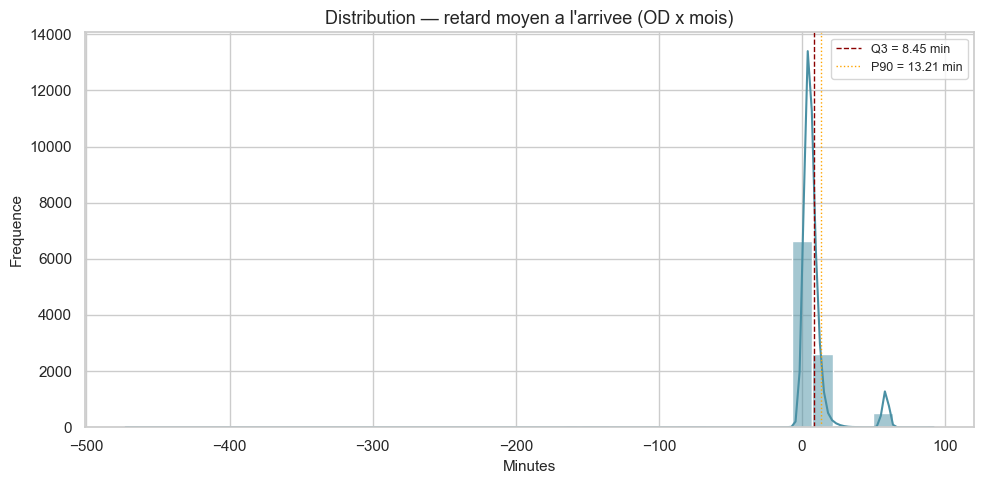

--- Synthese quantitative ---
 n valide = 9853
 Skewness (Pearson) = -2.743
 Q1 = 3.37 min | mediane = 5.41 min | Q3 = 8.45 min | P90 = 13.21 min
 Environ 75.0 % des observations sont au plus au Q3 (8.45 min), tandis que ~10.0 % depassent le 90e percentile.


In [38]:
DEL_ARR = "Average delay of all trains at arrival"

if DEL_ARR in df.columns:
    d = df[DEL_ARR].dropna()
    q25, q50, q75, q90 = d.quantile([0.25, 0.5, 0.75, 0.9])
    pct_le_q75 = (d <= q75).mean() * 100
    pct_ge_q90 = (d >= q90).mean() * 100
    sk = d.skew()

    fig, ax = plt.subplots(figsize=FIG["sm"])
    sns.histplot(d, kde=True, bins=40, color=PAL["delay"], ax=ax)
    ax.axvline(q75, color="darkred", linestyle="--", linewidth=1, label=f"Q3 = {q75:.2f} min")
    ax.axvline(q90, color="orange", linestyle=":", linewidth=1, label=f"P90 = {q90:.2f} min")
    ax.set_title("Distribution — retard moyen a l'arrivee (OD x mois)")
    ax.set_xlabel("Minutes")
    ax.set_ylabel("Frequence")
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()

    print("--- Synthese quantitative ---")
    print(f" n valide = {len(d)}")
    print(f" Skewness (Pearson) = {sk:.3f}")
    print(f" Q1 = {q25:.2f} min | mediane = {q50:.2f} min | Q3 = {q75:.2f} min | P90 = {q90:.2f} min")
    print(
        f" Environ {pct_le_q75:.1f} % des observations sont au plus au Q3 ({q75:.2f} min),"
        f" tandis que ~{pct_ge_q90:.1f} % depassent le 90e percentile."
    )

### 9.2 Boxplot — Service_clean

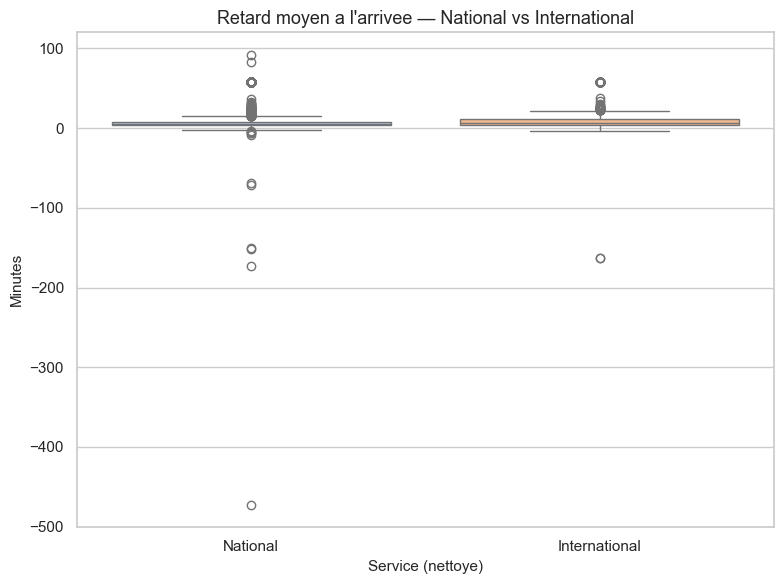

 National: mediane = 5.23 min | n = 8247
 International: mediane = 7.02 min | n = 1117


In [39]:
if "Service_clean" in df.columns and DEL_ARR in df.columns:
    plot_df = df.dropna(subset=["Service_clean", DEL_ARR])
    fig, ax = plt.subplots(figsize=FIG["sq"])
    sns.boxplot(data=plot_df, x="Service_clean", y=DEL_ARR, palette=PAL["box"], ax=ax)
    ax.set_title("Retard moyen a l'arrivee — National vs International")
    ax.set_xlabel("Service (nettoye)")
    ax.set_ylabel("Minutes")
    plt.tight_layout()
    plt.show()

    for svc in plot_df["Service_clean"].dropna().unique():
        sub = plot_df.loc[plot_df["Service_clean"] == svc, DEL_ARR]
        print(f" {svc}: mediane = {sub.median():.2f} min | n = {len(sub)}")

### 9.3 Top 15 gares de depart

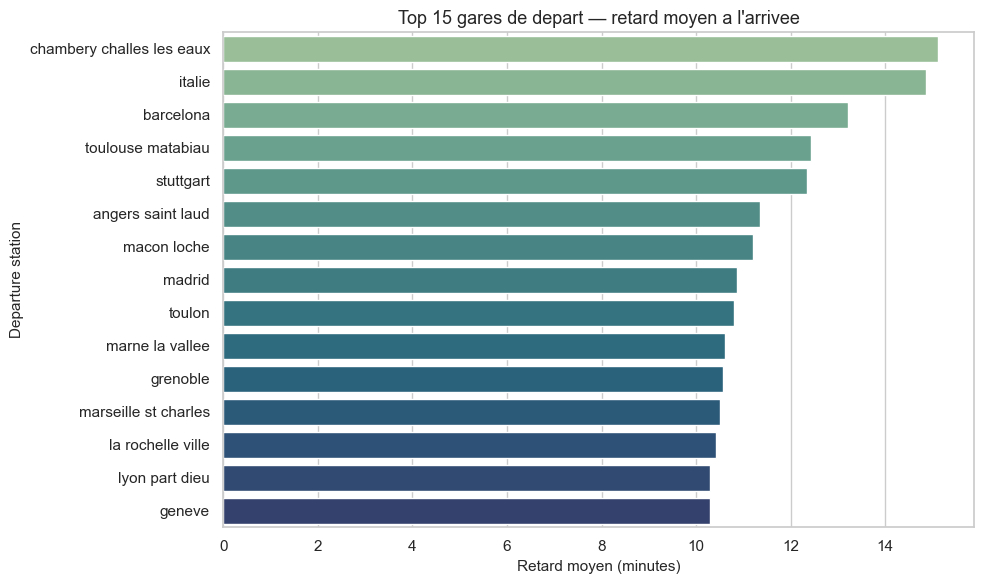

 Gare #1 : chambery challes les eaux — 15.12 min en moyenne.


In [40]:
ST = "Departure station"
if DEL_ARR in df.columns and ST in df.columns:
    top = df.groupby(ST, observed=True)[DEL_ARR].mean().sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=FIG["md"])
    sns.barplot(x=top.values, y=top.index, hue=top.index, palette=PAL["route"], legend=False, ax=ax)
    ax.set_title("Top 15 gares de depart — retard moyen a l'arrivee")
    ax.set_xlabel("Retard moyen (minutes)")
    plt.tight_layout()
    plt.show()

    worst = top.index[0]
    print(f" Gare #1 : {worst} — {top.iloc[0]:.2f} min en moyenne.")

### ⚠️ Problème détecté — normalisation des stations insuffisante

Le graphe ci-dessus révèle un problème critique : **Paris Lyon apparaît au moins 4 fois** sous des
graphies différentes (`parisolyon`, `parix lyon`, `paois lyon`, `paris ly0n`…).
Le `groupby` traite chaque variante comme une gare distincte → les moyennes sont **partielles et faussées**.

Même constat sur d'autres gares : `grenqble`, `makseille st charles`, `jennes`, `parfs est`…

**Cause :** le nettoyage actuel (`.str.lower().str.strip()`) ne corrige pas les fautes de frappe
dans le CSV source (caractères transposés, chiffre `0` à la place d'un `o`, lettres manquantes).

**Impact :** toute analyse par gare est inexploitable en l'état. Les features `Departure station`,
`Arrival station` et `route` sont compromises.

**Action requise :**
appliquer une correspondance floue (*fuzzy matching*) sur un référentiel de gares SNCF connu,
ou construire un dictionnaire de corrections manuel sur les cas les plus fréquents.

### 9.4 Routes & hotspots

--- Top 10 routes — retard moyen (n >= 3) ---


,route,mean_delay_arr,n_obs
0,unknown_dep_douai,30.74,4
1,unknown_dep_paris vaugirard,23.1,3
2,unknown_dep_angouleme,22.11,3
3,unknown_dep_toulouse matabiau,21.15,8
4,montpellier_unknown_arr,20.49,4
5,unknown_dep_madrid,16.66,4
6,unknown_dep_valence alixan tgv,16.06,4
7,chambery challes les eaux_paris lyon,15.44,72
8,paris montparnasse_toulouse matabiau,15.01,69
9,italie_paris lyon,14.94,72


--- Top 10 routes — cancel_rate moyen (n >= 3) ---


,route,mean_cancel_rate,n_obs
0,marseille st charles_madrid,0.8954,27
1,unknown_dep_francfort,0.4382,3
2,unknown_dep_saint etienne chateaucreux,0.3169,4
3,barcelona_unknown_arr,0.3064,5
4,strasbourg_nantes,0.2579,68
5,marseille st charles_unknown_arr,0.2367,16
6,tourcoing_bordeaux st jean,0.2346,59
7,unknown_dep_madrid,0.2343,3
8,bordeaux st jean_tourcoing,0.2292,69
9,saint etienne chateaucreux_paris lyon,0.2164,60


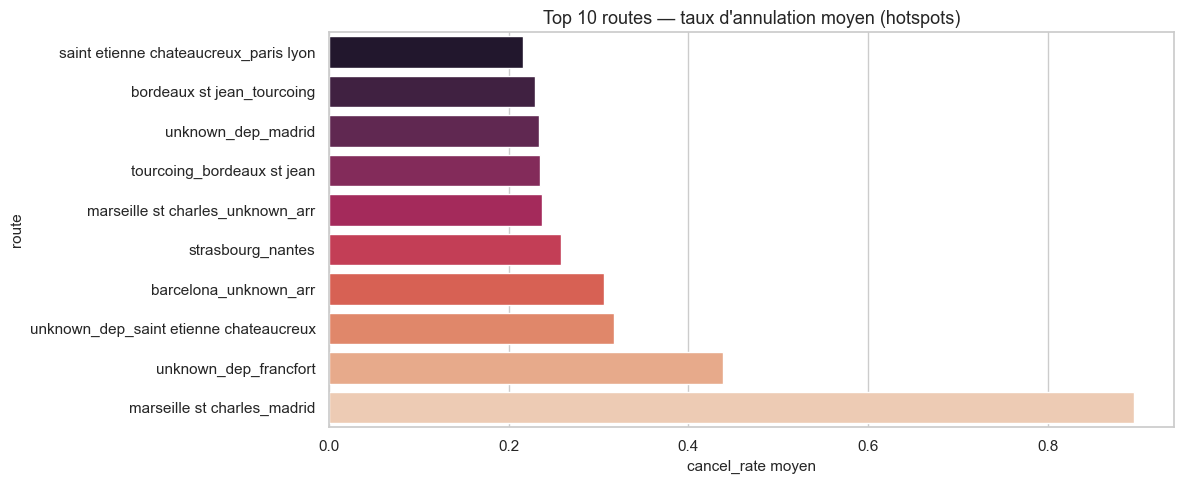

In [41]:
MIN_N = 3
if "route" in df.columns and DEL_ARR in df.columns:
    g = df.groupby("route", observed=True)[DEL_ARR].agg(["mean", "count"])
    g = g[g["count"] >= MIN_N].sort_values("mean", ascending=False)
    worst_routes_delay = g.head(10).reset_index()
    worst_routes_delay.columns = ["route", "mean_delay_arr", "n_obs"]
    print("--- Top 10 routes — retard moyen (n >= %d) ---" % MIN_N)
    display(worst_routes_delay)

if "route" in df.columns and "cancel_rate" in df.columns:
    gc = df.groupby("route", observed=True)["cancel_rate"].agg(["mean", "count"])
    gc = gc[gc["count"] >= MIN_N].sort_values("mean", ascending=False)
    hotspots_cancel = gc.head(10).reset_index()
    hotspots_cancel.columns = ["route", "mean_cancel_rate", "n_obs"]
    print("--- Top 10 routes — cancel_rate moyen (n >= %d) ---" % MIN_N)
    display(hotspots_cancel)

    fig, ax = plt.subplots(figsize=FIG["lg"])
    plot_r = gc.head(10).sort_values("mean").reset_index()
    sns.barplot(data=plot_r, x="mean", y="route", palette=PAL_CANCEL_BAR, ax=ax)
    ax.set_title("Top 10 routes — taux d'annulation moyen (hotspots)")
    ax.set_xlabel("cancel_rate moyen")
    plt.tight_layout()
    plt.show()

### 9.5 Serie temporelle mensuelle

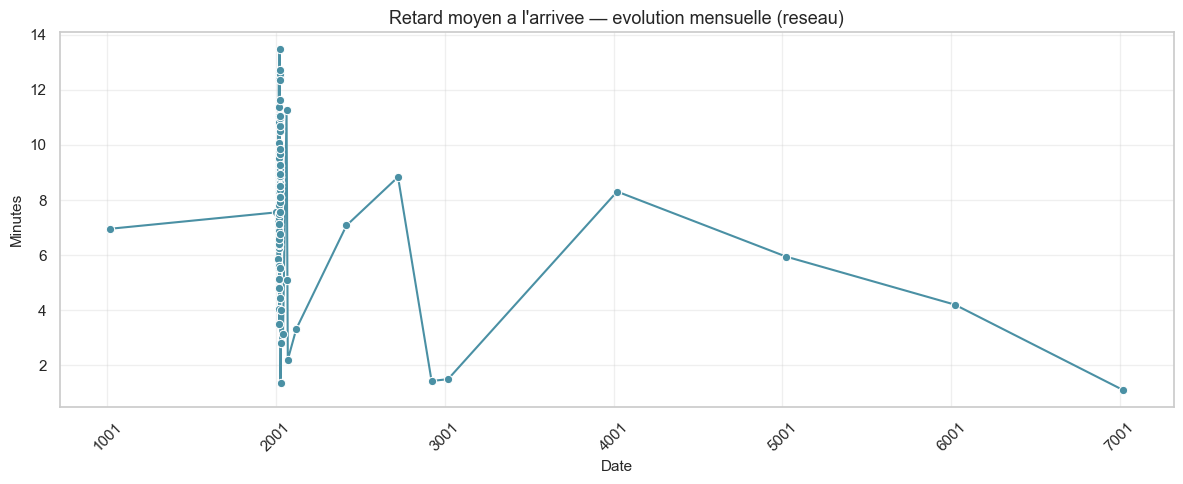

 Coefficient de variation mensuel (std/mean) : 0.340


In [42]:
if DEL_ARR in df.columns and "Date" in df.columns:
    ts = df.dropna(subset=["Date", DEL_ARR])
    monthly_delay = ts.groupby("Date", observed=True)[DEL_ARR].mean()

    fig, ax = plt.subplots(figsize=FIG["lg"])
    sns.lineplot(x=monthly_delay.index, y=monthly_delay.values, marker="o", color=PAL["delay"], ax=ax)
    ax.set_title("Retard moyen a l'arrivee — evolution mensuelle (reseau)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Minutes")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    cv = monthly_delay.std() / monthly_delay.mean() if monthly_delay.mean() != 0 else np.nan
    print(f" Coefficient de variation mensuel (std/mean) : {cv:.3f}")

### 9.6 Matrice de correlations

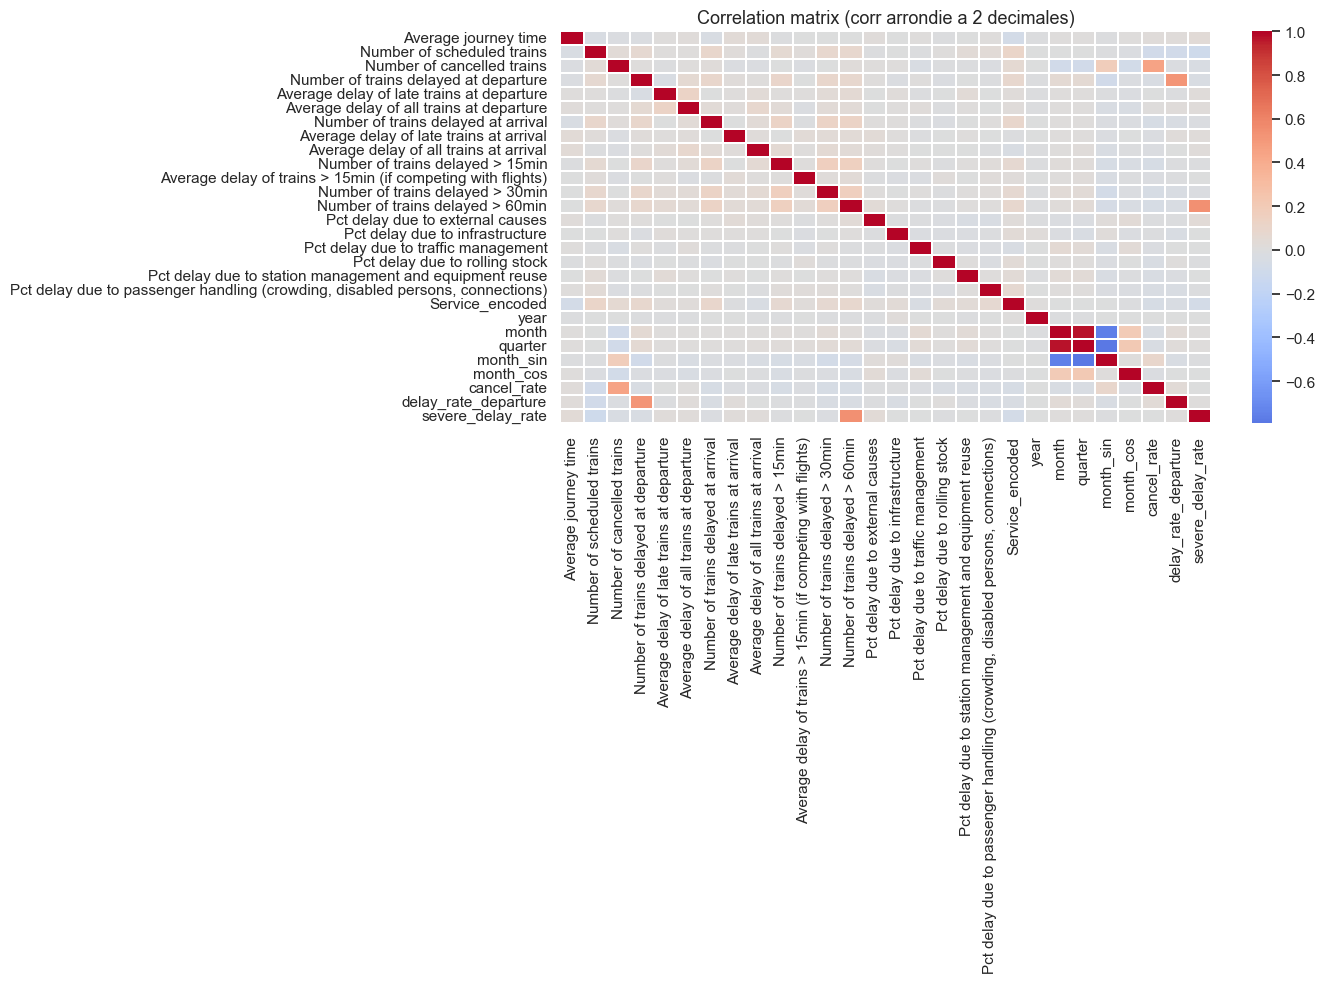

Correlations de Pearson (paires cles) :
  -0.0214  |  Number of cancelled trains  vs  Average delay of all trains at arrival
  0.0843  |  Average delay of all trains at departure  vs  Average delay of all trains at arrival
  0.0210  |  Number of cancelled trains  vs  Number of trains delayed > 60min


In [43]:
DEL_ARR = "Average delay of all trains at arrival"
clean_df = df

corr = clean_df.select_dtypes(include=np.number).corr().round(2)

fig, ax = plt.subplots(figsize=FIG["heat"])
sns.heatmap(corr, cmap=CMAP["corr"], center=0, linewidths=0.3, annot=False, ax=ax)
ax.set_title("Correlation matrix (corr arrondie a 2 decimales)")
plt.tight_layout()
plt.show()

pairs = [
    ("Number of cancelled trains", DEL_ARR),
    ("Average delay of all trains at departure", "Average delay of all trains at arrival"),
    ("Number of cancelled trains", "Number of trains delayed > 60min"),
]
pairs = [(a, b) for a, b in pairs if a in clean_df.columns and b in clean_df.columns]
print("Correlations de Pearson (paires cles) :")
for a, b in pairs:
    c0 = clean_df[a].corr(clean_df[b])
    print(f"  {c0:.4f}  |  {a[:45]}  vs  {b[:45]}")

### 9.7 Scatter annulations vs retard

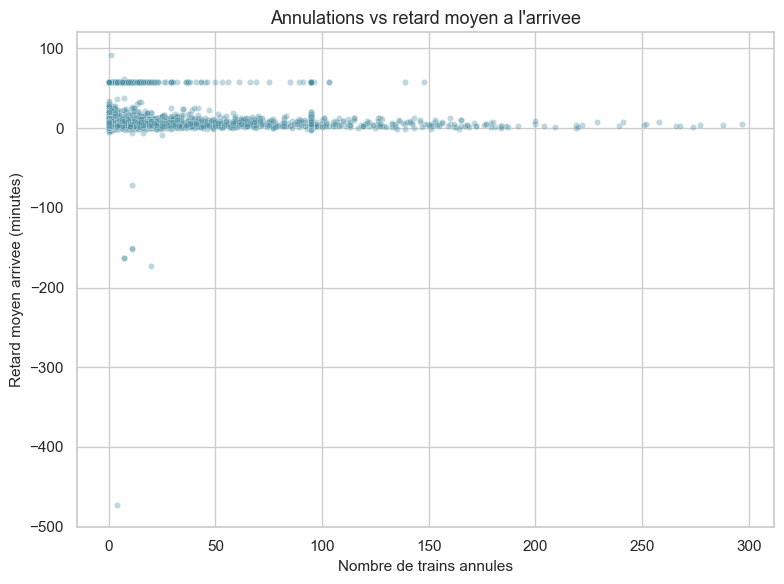

 Pearson (annulations vs retard moyen arrivee) : -0.0214


In [44]:
XC = "Number of cancelled trains"
if XC in df.columns and DEL_ARR in df.columns:
    r_sc = df[XC].corr(df[DEL_ARR])
    fig, ax = plt.subplots(figsize=FIG["sq"])
    sns.scatterplot(data=df, x=XC, y=DEL_ARR, alpha=0.35, s=20, color=PAL["delay"], ax=ax)
    ax.set_title("Annulations vs retard moyen a l'arrivee")
    ax.set_xlabel("Nombre de trains annules")
    ax.set_ylabel("Retard moyen arrivee (minutes)")
    plt.tight_layout()
    plt.show()
    print(f" Pearson (annulations vs retard moyen arrivee) : {r_sc:.4f}")

## 10. Export

In [45]:
OUT_PATH = "cleaned_dataset.csv"
df.to_csv(OUT_PATH, index=False)
print("Fichier ecrit :", OUT_PATH)
print("Shape final :", df.shape)

Fichier ecrit : cleaned_dataset.csv
Shape final : (10662, 34)


## 11. Limitations

- Colonnes commentaires retirees (pas d'analyse NLP des causes).
- Normalisation des gares rule-based ; variantes possibles.
- Granularite mois x OD — pas d'analyse horaire fine.
- Correlations lineaires seules.

## 12. Synthese — insights metier

Asymetrie des retards, hotspots gares/routes, serie temporelle pour monitoring / forecasting, vision multi-KPI.

## 13. Key Findings

In [46]:
DEL_ARR = "Average delay of all trains at arrival"
d = df[DEL_ARR].dropna()
sk = float(d.skew())
q75 = float(d.quantile(0.75))
pct_le_q75 = float((d <= q75).mean() * 100)
r_cd = df["Number of cancelled trains"].corr(df[DEL_ARR]) if "Number of cancelled trains" in df.columns else np.nan
r_da = (
    df["Average delay of all trains at departure"].corr(df[DEL_ARR])
    if "Average delay of all trains at departure" in df.columns
    else np.nan
)

print("Key Findings (this dataset, OD-month grain)")
print("-" * 55)
print(f"• Delay distribution: skewness ~ {sk:.2f} — tail behaviour matters for KPIs.")
print(f"• ~{pct_le_q75:.0f}% of observations fall at or below Q3 (~{q75:.1f} min).")
if "route" in df.columns:
    print("• Route-level rankings (see sec. 9.4): prioritize OD pairs with high delay or cancel_rate.")
print(f"• Pearson: cancellations vs arrival delay ~ {r_cd:.3f}; dep vs arr delay ~ {r_da:.3f}.")
print("• Monthly aggregation: use time-based validation for modelling.")
print("-" * 55)

Key Findings (this dataset, OD-month grain)
-------------------------------------------------------
• Delay distribution: skewness ~ -2.74 — tail behaviour matters for KPIs.
• ~75% of observations fall at or below Q3 (~8.4 min).
• Route-level rankings (see sec. 9.4): prioritize OD pairs with high delay or cancel_rate.
• Pearson: cancellations vs arrival delay ~ -0.021; dep vs arr delay ~ 0.084.
• Monthly aggregation: use time-based validation for modelling.
-------------------------------------------------------


- **Delay distributions** are often **asymmetric**; Q3 / P90 separate routine OD-months from severe episodes.
- **Routes** can rank high on mean delay or **cancel_rate** — check printed tables.
- **Cancellation vs delay** shows a **modest linear association** at this grain; combine with **rates** and routes.

*Validate on fresh data before executive decisions.*